# Análise - Pontuação Média dos Campeões por Ano

## 1. Introdução

Nesta análise exploratória de dados (EDA), buscamos investigar a evolução da pontuação dos campeões da Fórmula 1 ao longo dos anos. A motivação central é entender:

    - Se os campeões estão se distanciando mais dos vice-campeões;
    - Se existem épocas historicamente mais equilibradas ou dominadas por um único piloto.

## 2. Metodologia

#### 2.1 Bases de Dados Utilizadas

    - driver_standings.csv: Posição dos pilotos em cada corrida;
    - races.csv: Informações sobre o calendário de corridas e respectivos anos;
    - drivers.csv: Detalhes dos pilotos.

#### 2.2 Tratamento Inicial dos Dados

In [4]:
import pandas as pd

colocacao = pd.read_csv("driver_standings.csv", delimiter=",")
corridas = pd.read_csv("races.csv", delimiter=",")
pilotos = pd.read_csv("drivers.csv", delimiter=",")

# Associar cada classificação com o respectivo ano
colocacao = colocacao.merge(corridas[["raceId", "year"]], on="raceId")

# Obter apenas a última corrida de cada ano
ultima_corrida_id = corridas.groupby("year")["raceId"].max().reset_index()
colocacao_final = colocacao.merge(ultima_corrida_id, on=["year", "raceId"])

# Filtrar campeões e vices
campeoes = colocacao_final[colocacao_final["position"] == 1]
vices = colocacao_final[colocacao_final["position"] == 2]

# Juntar com nomes dos pilotos
campeoes = campeoes.merge(pilotos[["driverId", "forename", "surname"]], on="driverId")
vices = vices.merge(pilotos[["driverId", "forename", "surname"]], on="driverId")
campeoes["driver_name"] = campeoes["forename"] + ' ' + campeoes["surname"]
vices["vice_name"] = vices["forename"] + ' ' + vices["surname"]

## 4. Análise dos Dados

In [ ]:
dominancia = campeoes[["year", "points", "driver_name"]].merge(
    vices[["year", "points", "vice_name"]],
    on="year",
    suffixes=("_campeao", "_vice")
)

dominancia["diferenca"] = dominancia["points_campeao"] - dominancia["points_vice"]

print(dominancia)


    year  points_campeao         driver_name  points_vice           vice_name  \
0   2008            98.0      Lewis Hamilton         97.0        Felipe Massa   
1   2007           110.0      Kimi Räikkönen        109.0      Lewis Hamilton   
2   2006           134.0     Fernando Alonso        121.0  Michael Schumacher   
3   2005           133.0     Fernando Alonso        112.0      Kimi Räikkönen   
4   2004           148.0  Michael Schumacher        114.0  Rubens Barrichello   
..   ...             ...                 ...          ...                 ...   
70  2020           347.0      Lewis Hamilton        223.0     Valtteri Bottas   
71  2021           395.5      Max Verstappen        387.5      Lewis Hamilton   
72  2022           454.0      Max Verstappen        308.0     Charles Leclerc   
73  2023           575.0      Max Verstappen        285.0        Sergio Pérez   
74  2024           437.0      Max Verstappen        374.0        Lando Norris   

    diferenca  
0         1

## 5. Conclusão

A análise permite observar que:

    - Alguns anos apresentam equilíbrio, com diferenças de pontuação mínimas (ex: 2007);
    - Outros anos apresentam domínio extremo, com campeões muito à frente do vice (ex: 2013, 2020);
    - A mudança no sistema de pontuação ao longo do tempo deve ser considerada na hora de interpretar uma comparação entre os anos

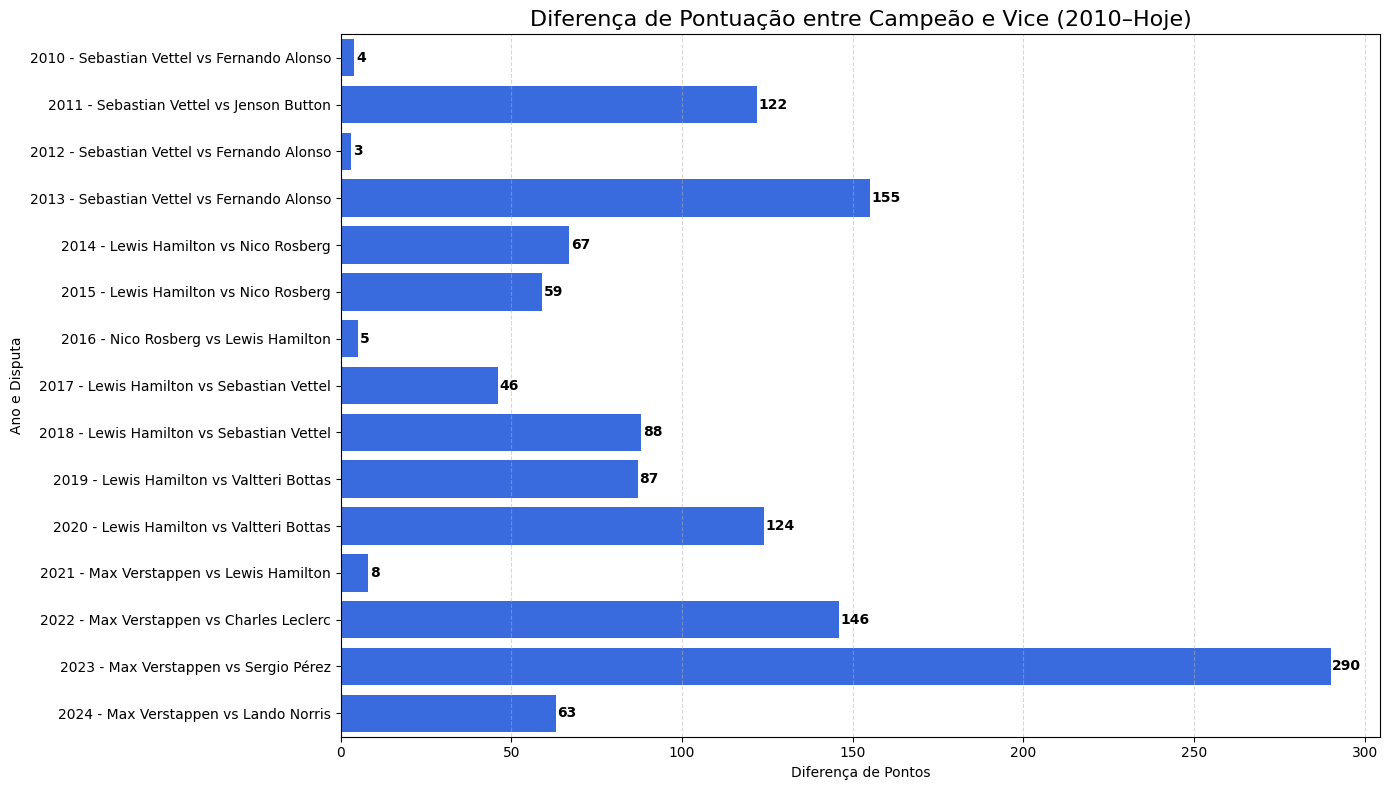

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar dados a partir de 2010
dominancia_2010 = dominancia[dominancia["year"] >= 2010].copy()

# Criar identificador personalizado
dominancia_2010["Identificador"] = dominancia_2010.apply(
    lambda row: f"{row['year']} - {row['driver_name']} vs {row['vice_name']}", axis=1
)

# Ordenar do mais antigo para o mais recente
dominancia_2010 = dominancia_2010.sort_values("year", ascending=True).reset_index(drop=True)

# Plotar gráfico de barras horizontais
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=dominancia_2010,
    y="Identificador",
    x="diferenca",
    color="#1F60F9"  # Azul Red Bull
)

# Obter posições y dos ticks
yticks = ax.get_yticks()

# Colocar o valor ao lado direito de cada barra
for i, (pos_y, diferenca) in enumerate(zip(yticks, dominancia_2010["diferenca"])):
    ax.text(
        diferenca + 0.5,  # posiciona à direita da barra
        pos_y,
        f"{int(diferenca)}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Estilo
plt.title("Diferença de Pontuação entre Campeão e Vice (2010–Hoje)", fontsize=16)
plt.xlabel("Diferença de Pontos")
plt.ylabel("Ano e Disputa")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
